# Módulo 4: Canal Selectivo en Frecuencia

Este notebook agrega un canal selectivo en frecuencia (multipath) al sistema LoRa,
combinándolo con el ruido AWGN del Módulo 3.

## Contenido

1. Función de canal multipath
2. Visualización de la respuesta en frecuencia del canal
3. Efecto del canal sobre un chirp
4. Canal completo: multipath + AWGN
5. Barrido BER vs SNR con canal selectivo
6. Comparación contra canal AWGN puro


## 1. Librerías e imports de módulos anteriores

In [13]:
import numpy as np
import matplotlib.pyplot as plt

# ---------- Módulo 1 ----------
def codificador(bits, SF):
    bits = np.array(bits)
    if len(bits) % SF != 0:
        raise ValueError(f"La cantidad de bits ({len(bits)}) debe ser múltiplo de SF ({SF})")
    num_simbolos = len(bits) // SF
    simbolos = np.zeros(num_simbolos, dtype=int)
    for i in range(num_simbolos):
        bloque = bits[i * SF : (i + 1) * SF]
        valor = 0
        for posicion, bit in enumerate(bloque):
            valor += bit * 2 ** (SF - 1 - posicion)
        simbolos[i] = valor
    return simbolos

def decodificador(simbolos, SF):
    simbolos = np.array(simbolos, dtype=int)
    bits = np.zeros(len(simbolos) * SF, dtype=int)
    for i, simbolo in enumerate(simbolos):
        valor_restante = int(simbolo)
        for posicion in range(SF):
            peso = 2 ** (SF - 1 - posicion)
            if valor_restante >= peso:
                bits[i * SF + posicion] = 1
                valor_restante -= peso
    return bits

def calcular_ber(bits_tx, bits_rx):
    bits_tx = np.array(bits_tx); bits_rx = np.array(bits_rx)
    if len(bits_tx) != len(bits_rx):
        raise ValueError("Los vectores deben tener la misma longitud")
    return np.sum(bits_tx != bits_rx) / len(bits_tx)

# ---------- Módulo 2 ----------
def up_chirp_base(SF, BW):
    N = 2**SF
    chirp = np.zeros(N, dtype=complex)
    for k in range(N):
        chirp[k] = np.exp(1j * 2 * np.pi * (k**2 / (2*N) - k/2))
    return chirp

def down_chirp(SF, BW):
    return np.conj(up_chirp_base(SF, BW))

def waveform_former(simbolos, SF, BW):
    N = 2**SF
    simbolos = np.array(simbolos)
    chirp_base = up_chirp_base(SF, BW)
    waveform = np.zeros((len(simbolos), N), dtype=complex)
    for i, s in enumerate(simbolos):
        waveform[i] = np.roll(chirp_base, -s)
    return waveform

def n_tuple_former(waveform, SF, BW):
    dc = down_chirp(SF, BW)
    num_simbolos = waveform.shape[0]
    simbolos_rx = np.zeros(num_simbolos, dtype=int)
    for i in range(num_simbolos):
        dechirped = waveform[i] * dc
        espectro = np.fft.fft(dechirped)
        simbolos_rx[i] = np.argmax(np.abs(espectro))
    return simbolos_rx

# ---------- Módulo 3 ----------
def agregar_ruido_awgn(waveform, snr_db):
    potencia_senal = np.mean(np.abs(waveform)**2)
    snr_lineal = 10 ** (snr_db / 10)
    potencia_ruido = potencia_senal / snr_lineal
    desviacion = np.sqrt(potencia_ruido / 2)
    ruido = desviacion * (np.random.randn(*waveform.shape) +
                          1j * np.random.randn(*waveform.shape))
    return waveform + ruido

# ---------- Parámetros ----------
SF = 7
BW = 125e3
N  = 2**SF

# ---------- Modulación FSK (Ecuación 17 de Vangelista, para comparación) ----------
def waveform_former_fsk(simbolos, SF, BW):
    N = 2**SF
    simbolos = np.array(simbolos)
    k = np.arange(N)
    wf = np.zeros((len(simbolos), N), dtype=complex)
    for i, s in enumerate(simbolos):
        wf[i] = np.exp(1j * 2 * np.pi * s * k / N)
    return wf

def n_tuple_former_fsk(waveform, SF, BW):
    simbolos_rx = np.zeros(waveform.shape[0], dtype=int)
    for i in range(waveform.shape[0]):
        simbolos_rx[i] = np.argmax(np.abs(np.fft.fft(waveform[i])))
    return simbolos_rx

print("Módulos 1, 2 y 3 cargados correctamente.")
print(f"Parámetros: SF={SF}, BW={BW/1e3:.0f} kHz, N={N}")

Módulos 1, 2 y 3 cargados correctamente.
Parámetros: SF=7, BW=125 kHz, N=128


## 2. Modelo del canal multipath

In [14]:
def crear_canal_vangelista():
    """
    Crea la respuesta al impulso del canal multipath:

        h(nT) = sqrt(0.8)*delta(nT) + sqrt(0.2)*delta(nT-T)

    Retorna
    -------
    h : np.array complejo de 2 muestras (energía unitaria)
    """
    h = np.array([np.sqrt(0.8), np.sqrt(0.2)], dtype=complex)
    return h

h = crear_canal_vangelista()

print("Respuesta al impulso h:")
for i, coef in enumerate(h):
    print(f"  h[{i}] = {coef.real:.4f}  (retardo {i} muestra{'s' if i!=1 else ''})")

print(f"\nEnergía total: {np.sum(np.abs(h)**2):.4f}  (debe ser 1.0, 'unit energy')")

Respuesta al impulso h:
  h[0] = 0.8944  (retardo 0 muestras)
  h[1] = 0.4472  (retardo 1 muestra)

Energía total: 1.0000  (debe ser 1.0, 'unit energy')


## 3. Visualización: respuesta en frecuencia del canal

La respuesta en frecuencia del canal es la FFT de su respuesta al impulso `h`.
Muestra cuánto atenúa (o amplifica) el canal a cada frecuencia.

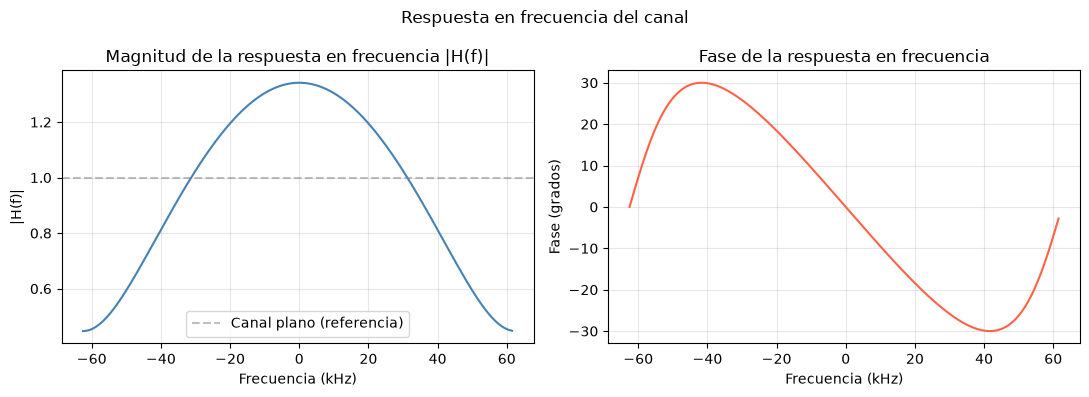

Ganancia máxima: 1.342
Ganancia mínima: 0.447
Variación total: 9.5 dB


In [15]:
H = np.fft.fft(h, n=N)
freqs = np.fft.fftfreq(N, d=1/BW) / 1e3   # frecuencias en kHz

fig, axs = plt.subplots(1, 2, figsize=(11, 4))

axs[0].plot(np.fft.fftshift(freqs),
            np.fft.fftshift(np.abs(H)), color='steelblue')
axs[0].set_title("Magnitud de la respuesta en frecuencia |H(f)|")
axs[0].set_xlabel("Frecuencia (kHz)")
axs[0].set_ylabel("|H(f)|")
axs[0].axhline(1.0, color='gray', linestyle='--', alpha=0.5, label='Canal plano (referencia)')
axs[0].legend()
axs[0].grid(True, alpha=0.3)

axs[1].plot(np.fft.fftshift(freqs),
            np.fft.fftshift(np.angle(H) * 180 / np.pi), color='tomato')
axs[1].set_title("Fase de la respuesta en frecuencia")
axs[1].set_xlabel("Frecuencia (kHz)")
axs[1].set_ylabel("Fase (grados)")
axs[1].grid(True, alpha=0.3)

plt.suptitle("Respuesta en frecuencia del canal", fontsize=12)
plt.tight_layout()
plt.show()

print(f"Ganancia máxima: {np.max(np.abs(H)):.3f}")
print(f"Ganancia mínima: {np.min(np.abs(H)):.3f}")
print(f"Variación total: {20*np.log10(np.max(np.abs(H))/np.min(np.abs(H))):.1f} dB")

## 4. Función de canal selectivo en frecuencia

Aplicar el canal es convolucionar cada chirp con `h`.

In [16]:
def aplicar_canal_selectivo(waveform, h):
    """
    Aplica un canal multipath a una matriz de waveforms LoRa.

    Para cada chirp (fila de la matriz), convoluciona con la respuesta
    al impulso h del canal y trunca el resultado a N muestras.

    Parámetros
    ----------
    waveform : np.array complejo de shape (num_simbolos, N)
    h        : np.array complejo — respuesta al impulso del canal

    Retorna
    -------
    waveform_distorsionada : np.array complejo de shape (num_simbolos, N)
    """
    num_simbolos, N = waveform.shape
    waveform_dist = np.zeros((num_simbolos, N), dtype=complex)

    for i in range(num_simbolos):
        resultado_completo = np.convolve(waveform[i], h, mode='full')
        waveform_dist[i] = resultado_completo[:N]

    return waveform_dist

# Prueba: aplicamos el canal a un chirp y verificamos la shape
wf_prueba = waveform_former([45], SF, BW)
wf_canal  = aplicar_canal_selectivo(wf_prueba, h)
print(f"Shape entrada : {wf_prueba.shape}")
print(f"Shape salida  : {wf_canal.shape}  (se mantiene igual)")

Shape entrada : (1, 128)
Shape salida  : (1, 128)  (se mantiene igual)


## 5. Visualización: efecto del canal sobre un chirp

Comparamos la parte real del chirp original vs el chirp después del canal multipath.


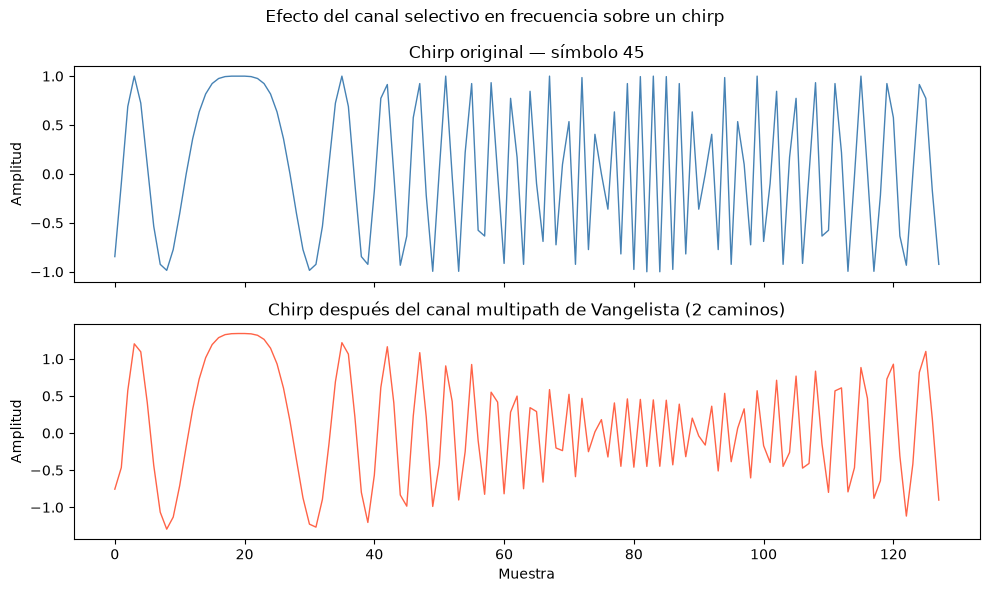

In [17]:
np.random.seed(3)
s_demo = 45
wf_limpio = waveform_former([s_demo], SF, BW)
wf_distorsionado = aplicar_canal_selectivo(wf_limpio, h)

fig, axs = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

axs[0].plot(np.real(wf_limpio[0]), color='steelblue', linewidth=1)
axs[0].set_title(f"Chirp original — símbolo {s_demo}")
axs[0].set_ylabel("Amplitud")

axs[1].plot(np.real(wf_distorsionado[0]), color='tomato', linewidth=1)
axs[1].set_title(f"Chirp después del canal multipath de Vangelista (2 caminos)")
axs[1].set_ylabel("Amplitud")
axs[1].set_xlabel("Muestra")

plt.suptitle("Efecto del canal selectivo en frecuencia sobre un chirp", fontsize=12)
plt.tight_layout()
plt.show()

## 6. Canal completo: multipath + AWGN

La cadena del canal real combina los dos efectos en orden:
1. Primero la señal pasa por el canal multipath (distorsión espectral)
2. Después se suma el ruido AWGN (ruido térmico)

$$y[n] = (x[n] * h[n]) + w[n]$$


In [18]:
def canal_completo(waveform, h, snr_db):
    """
    Aplica canal multipath seguido de ruido AWGN.
    """
    waveform_multipath = aplicar_canal_selectivo(waveform, h)
    waveform_rx = agregar_ruido_awgn(waveform_multipath, snr_db)
    return waveform_rx

print("Función canal_completo definida.")

Función canal_completo definida.


## 7. Barrido BER vs SNR — canal selectivo en frecuencia

Repetimos el mismo barrido del Módulo 3 pero ahora con el canal completo
(multipath + AWGN) para poder comparar ambas curvas. Usamos el mismo rango
de SNR de Vangelista (−12 a −1 dB), y un tamaño de muestra más acotado
(20 símbolos por punto) para mantener los tiempos de cómputo razonables,
dado que estamos principalmente interesados en la forma comparativa de
las curvas, no en una estimación de BER de alta precisión estadística.


In [19]:
np.random.seed(99)

snr_range = np.arange(-12, 0, 1)   # mismo rango que el Módulo 3 (Vangelista Fig. 1)
num_bits_por_punto = 20 * SF        # tamaño de muestra acotado
ber_selectivo = []

print(f"{'SNR (dB)':>10} | {'BER selectivo':>15} | {'Errores/Total':>15}")
print("-" * 48)

for snr in snr_range:
    bits_tx = np.random.randint(0, 2, num_bits_por_punto)
    simbolos_tx = codificador(bits_tx, SF)

    wf = waveform_former(simbolos_tx, SF, BW)
    wf_rx = canal_completo(wf, h, snr)

    simbolos_rx = n_tuple_former(wf_rx, SF, BW)
    bits_rx = decodificador(simbolos_rx, SF)

    ber = calcular_ber(bits_tx, bits_rx)
    ber_selectivo.append(ber)

    errores = int(ber * len(bits_tx))
    print(f"{snr:>10} | {ber:>15.6f} | {errores:>6} / {len(bits_tx)}")

ber_selectivo = np.array(ber_selectivo)

  SNR (dB) |   BER selectivo |   Errores/Total
------------------------------------------------
       -12 |        0.078571 |     11 / 140
       -11 |        0.071429 |     10 / 140
       -10 |        0.050000 |      7 / 140
        -9 |        0.000000 |      0 / 140
        -8 |        0.000000 |      0 / 140
        -7 |        0.000000 |      0 / 140
        -6 |        0.021429 |      3 / 140
        -5 |        0.000000 |      0 / 140
        -4 |        0.000000 |      0 / 140
        -3 |        0.000000 |      0 / 140
        -2 |        0.000000 |      0 / 140
        -1 |        0.000000 |      0 / 140


## 8. FSK en canal selectivo

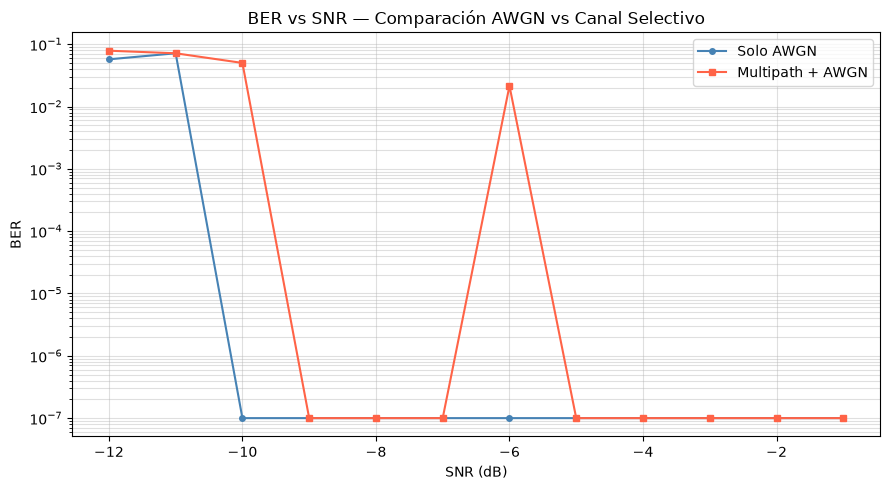

In [20]:
np.random.seed(99)
ber_awgn = []
for snr in snr_range:
    bits_tx = np.random.randint(0, 2, num_bits_por_punto)
    simbolos_tx = codificador(bits_tx, SF)
    wf = waveform_former(simbolos_tx, SF, BW)
    wf_rx = agregar_ruido_awgn(wf, snr)
    simbolos_rx = n_tuple_former(wf_rx, SF, BW)
    bits_rx = decodificador(simbolos_rx, SF)
    ber_awgn.append(calcular_ber(bits_tx, bits_rx))
ber_awgn = np.array(ber_awgn)

fig, ax = plt.subplots(figsize=(9, 5))

ax.semilogy(snr_range, np.where(ber_awgn > 0, ber_awgn, 1e-7),
            marker='o', markersize=4, linewidth=1.5,
            color='steelblue', label='Solo AWGN')

ax.semilogy(snr_range, np.where(ber_selectivo > 0, ber_selectivo, 1e-7),
            marker='s', markersize=4, linewidth=1.5,
            color='tomato', label='Multipath + AWGN')

ax.set_xlabel("SNR (dB)")
ax.set_ylabel("BER")
ax.set_title(f"BER vs SNR — Comparación AWGN vs Canal Selectivo")
ax.legend()
ax.grid(True, which='both', alpha=0.4)
plt.tight_layout()
plt.show()

In [21]:
np.random.seed(99)
ber_fsk_selectivo = []

for snr in snr_range:
    bits_tx = np.random.randint(0, 2, num_bits_por_punto)
    simbolos_tx = codificador(bits_tx, SF)

    wf_fsk = waveform_former_fsk(simbolos_tx, SF, BW)
    wf_fsk_canal = aplicar_canal_selectivo(wf_fsk, h)
    wf_fsk_rx = agregar_ruido_awgn(wf_fsk_canal, snr)

    simbolos_rx = n_tuple_former_fsk(wf_fsk_rx, SF, BW)
    bits_rx = decodificador(simbolos_rx, SF)

    ber_fsk_selectivo.append(calcular_ber(bits_tx, bits_rx))

ber_fsk_selectivo = np.array(ber_fsk_selectivo)

# También recalculamos FSK en AWGN puro (canal plano) para tener las 4 curvas
np.random.seed(99)
ber_fsk_awgn = []
for snr in snr_range:
    bits_tx = np.random.randint(0, 2, num_bits_por_punto)
    simbolos_tx = codificador(bits_tx, SF)
    wf_fsk = waveform_former_fsk(simbolos_tx, SF, BW)
    wf_fsk_rx = agregar_ruido_awgn(wf_fsk, snr)
    simbolos_rx = n_tuple_former_fsk(wf_fsk_rx, SF, BW)
    bits_rx = decodificador(simbolos_rx, SF)
    ber_fsk_awgn.append(calcular_ber(bits_tx, bits_rx))
ber_fsk_awgn = np.array(ber_fsk_awgn)

print("BER de FSK calculada en canal plano y en canal selectivo.")

BER de FSK calculada en canal plano y en canal selectivo.


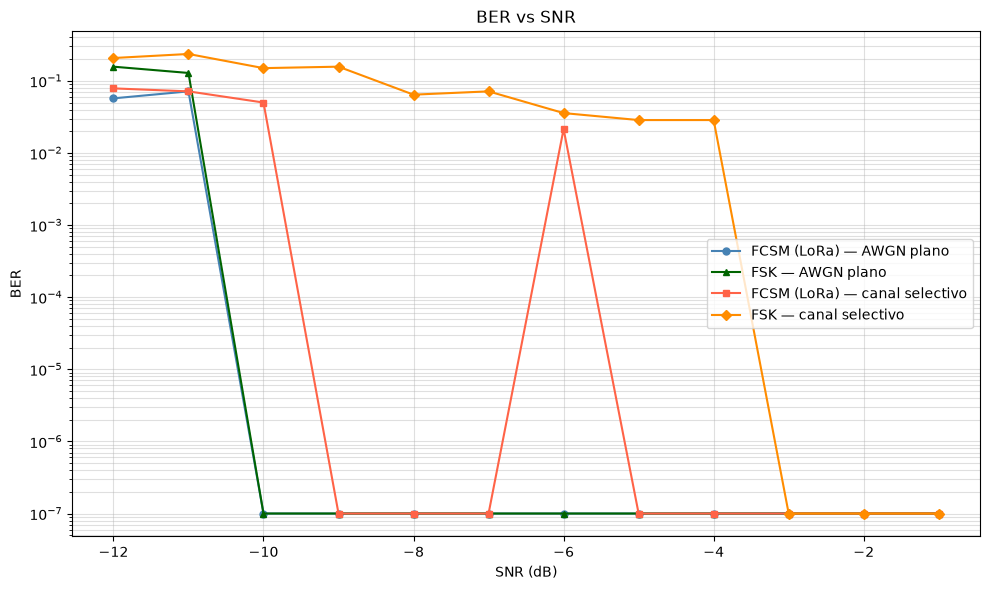

In [22]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.semilogy(snr_range, np.where(ber_awgn > 0, ber_awgn, 1e-7),
            marker='o', markersize=5, linewidth=1.5,
            color='steelblue', label='FCSM (LoRa) — AWGN plano')

ax.semilogy(snr_range, np.where(ber_fsk_awgn > 0, ber_fsk_awgn, 1e-7),
            marker='^', markersize=5, linewidth=1.5, linestyle='-',
            color='darkgreen', label='FSK — AWGN plano')

ax.semilogy(snr_range, np.where(ber_selectivo > 0, ber_selectivo, 1e-7),
            marker='s', markersize=5, linewidth=1.5,
            color='tomato', label='FCSM (LoRa) — canal selectivo')

ax.semilogy(snr_range, np.where(ber_fsk_selectivo > 0, ber_fsk_selectivo, 1e-7),
            marker='D', markersize=5, linewidth=1.5,
            color='darkorange', label='FSK — canal selectivo')

ax.set_xlabel("SNR (dB)")
ax.set_ylabel("BER")
ax.set_title(f"BER vs SNR")
ax.legend()
ax.grid(True, which='both', alpha=0.4)
plt.tight_layout()
plt.show()

## 9. Curva BER vs SNR — comparación FCSM: AWGN vs selectivo


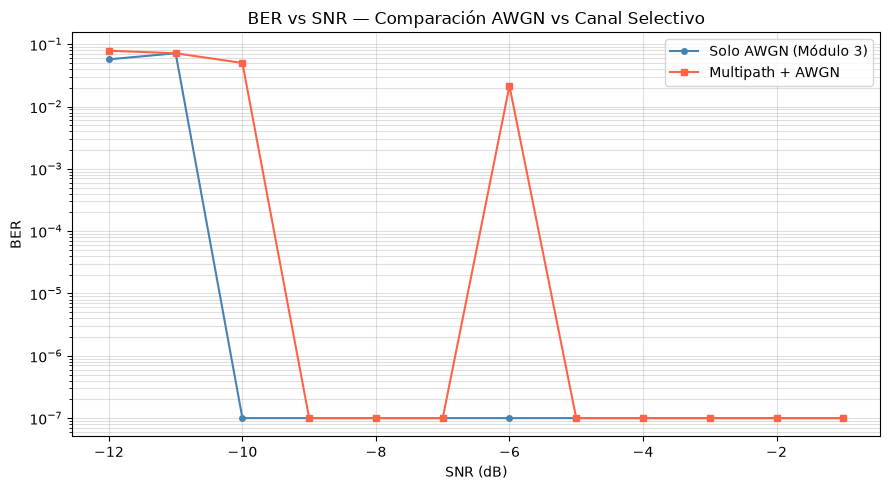

In [23]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.semilogy(snr_range, np.where(ber_awgn > 0, ber_awgn, 1e-7),
            marker='o', markersize=4, linewidth=1.5,
            color='steelblue', label='Solo AWGN (Módulo 3)')

ax.semilogy(snr_range, np.where(ber_selectivo > 0, ber_selectivo, 1e-7),
            marker='s', markersize=4, linewidth=1.5,
            color='tomato', label='Multipath + AWGN')

ax.set_xlabel("SNR (dB)")
ax.set_ylabel("BER")
ax.set_title(f"BER vs SNR — Comparación AWGN vs Canal Selectivo")
ax.legend()
ax.grid(True, which='both', alpha=0.4)
plt.tight_layout()
plt.show()

## 10. Análisis de resultados

In [24]:
def snr_corte(snr_range, ber_array, umbral=0.01):
    for snr, ber in zip(snr_range, ber_array):
        if ber < umbral:
            return snr
    return None

corte_awgn = snr_corte(snr_range, ber_awgn)
corte_sel  = snr_corte(snr_range, ber_selectivo)

print("=== Comparación de resultados ===")
print(f"Canal AWGN puro         — BER < 1% a partir de: {corte_awgn} dB")
print(f"Canal selectivo         — BER < 1% a partir de: {corte_sel} dB")

if corte_awgn is not None and corte_sel is not None:
    degradacion = corte_sel - corte_awgn
    print(f"Degradación por multipath: {degradacion:+d} dB de SNR necesario")

=== Comparación de resultados ===
Canal AWGN puro         — BER < 1% a partir de: -10 dB
Canal selectivo         — BER < 1% a partir de: -9 dB
Degradación por multipath: +1 dB de SNR necesario
